<a href="https://colab.research.google.com/github/angkonn/Paper_Replications/blob/main/DCNN_Silicon_Wafer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle
!pip install opencv-python-headless

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.multiclass import OutputCodeClassifier
from sklearn.svm import SVC
from tqdm import tqdm

In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d qingyi/wm811k-wafer-map
!unzip wm811k-wafer-map.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map
License(s): CC0-1.0
Archive:  wm811k-wafer-map.zip
  inflating: LSWMD.pkl               


# Data Preprocessing (Histogram equalization)

In [8]:
# Load CSV
df = pd.read_pickle('LSWMD.pkl')
df = df[['waferMap', 'failureType']]
df = df[df['failureType'] != 'none']



In [10]:
# Image Conversion and preprocessing function
def process_wafer_map(wafer_map, target_size=(32, 32)):
    # wafer_map is already a numpy array, no need for eval()

    wafer_map = np.array(wafer_map).astype(np.uint8)

# Resize and histogram equalization
    resized = cv2.resize(wafer_map, target_size)
    equalized = cv2.equalizeHist(resized)

    # Converting grascale into rgb
    rgb = np.stack([equalized]*3, axis=-1)
    return rgb / 255.0  # normalization

# data preprocessing
X = np.array([process_wafer_map(wm) for wm in tqdm(df['waferMap'])])
# Convert failureType to strings before encoding
y = df['failureType'].astype(str).astype('category').cat.codes.values  #
# label encoding

# Train, test, split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


100%|██████████| 25519/25519 [00:00<00:00, 27323.35it/s]


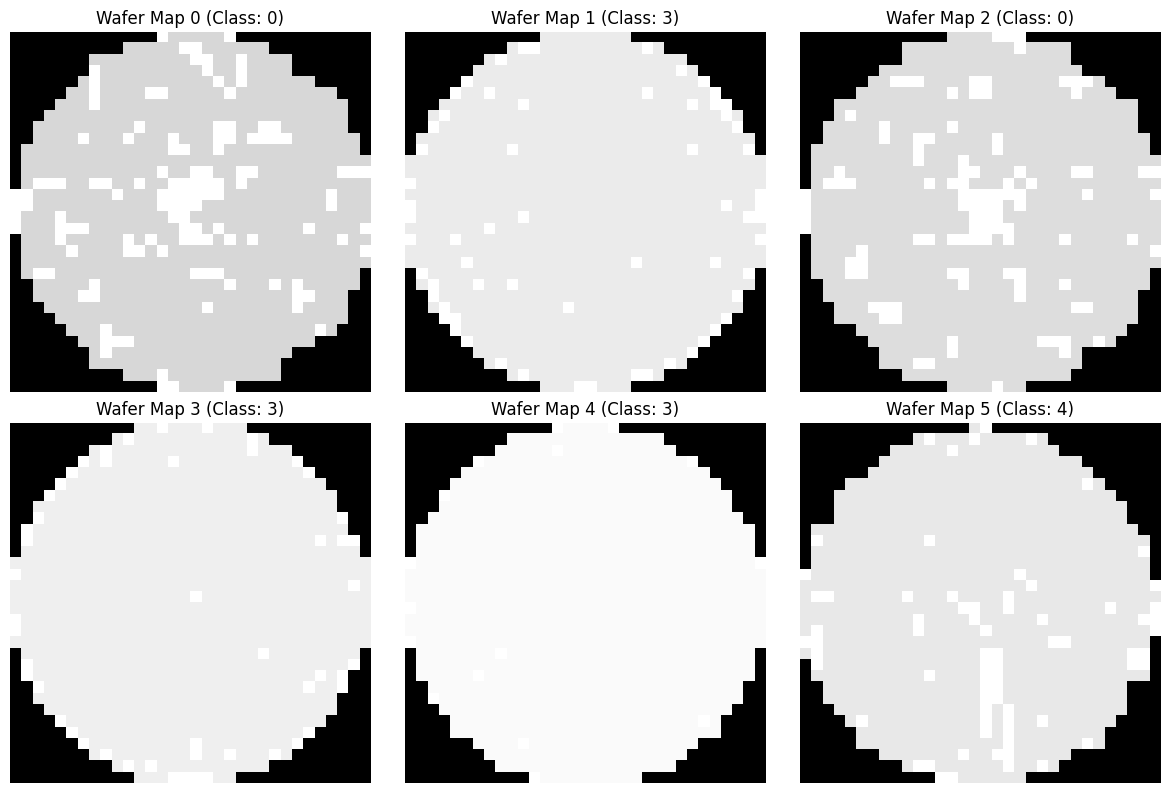

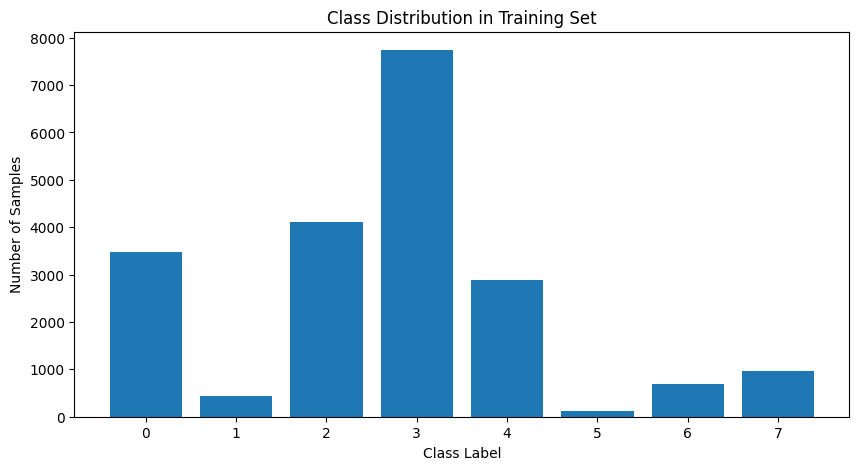

X_train shape: (20415, 32, 32, 3)
y_train shape: (20415,)
X_test shape: (5104, 32, 32, 3)
y_test shape: (5104,)


In [12]:
# visualize what happened above with explanation

import numpy as np
import matplotlib.pyplot as plt

# Visualize a few processed wafer maps
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    ax = axes[i // 3, i % 3]
    ax.imshow(X_train[i])
    ax.set_title(f"Wafer Map {i} (Class: {y_train[i]})")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Visualize the class distribution
plt.figure(figsize=(10, 5))
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Set")
plt.show()

# Display the shape of the training and testing data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


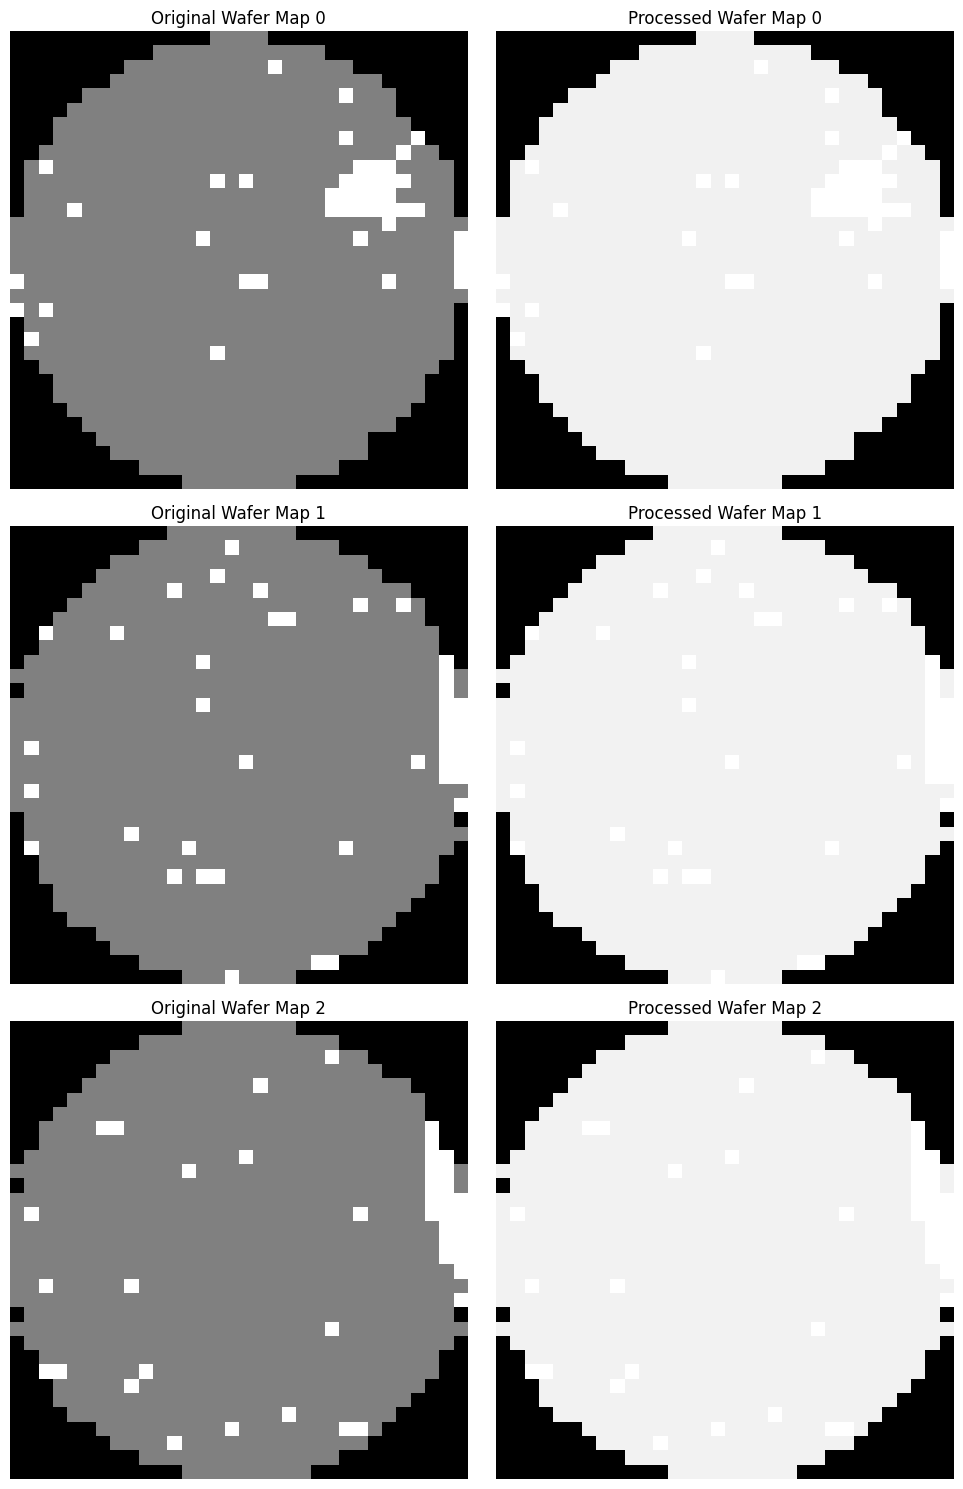

In [13]:
# prompt: visualize what happened before and after histogram equalization now

import matplotlib.pyplot as plt
import cv2
import numpy as np

# Assuming 'df' and 'process_wafer_map' are defined as in the previous code

# Select a few samples from the DataFrame
sample_indices = [0, 1, 2]  # Choose any indices
samples = df.iloc[sample_indices]

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(10, 15))

for i, index in enumerate(sample_indices):
  original_wafer_map = np.array(samples['waferMap'].iloc[i]).astype(np.uint8)

  # Resize the original wafer map (optional, but helps for comparison)
  resized_original = cv2.resize(original_wafer_map, (32, 32))

  processed_wafer_map = process_wafer_map(samples['waferMap'].iloc[i])

  # Convert processed image back to uint8 for display (if necessary)
  processed_wafer_map_uint8 = (processed_wafer_map * 255).astype(np.uint8)

  axes[i, 0].imshow(resized_original, cmap='gray')  # Display original wafermap in grayscale
  axes[i, 0].set_title(f"Original Wafer Map {index}")
  axes[i, 0].axis('off')

  axes[i, 1].imshow(processed_wafer_map_uint8)  # Display processed wafermap
  axes[i, 1].set_title(f"Processed Wafer Map {index}")
  axes[i, 1].axis('off')
plt.tight_layout()
plt.show()


# Creating dataloaders

In [15]:
class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)  # [B, C, H, W]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# creating dataloader
batch_size = 512
train_dataset = WaferDataset(X_train, y_train)
test_dataset = WaferDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# DCNN model definition (including swish activation)

In [16]:
# Swish activation function
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# DCNN architecture
class DCNN(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding='same'),  # 32x32x32
            Swish(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),  # 16x16x32

            nn.Conv2d(32, 64, kernel_size=5, padding='same'),  # 16x16x64
            Swish(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),  # 8x8x64

            nn.Conv2d(64, 128, kernel_size=5, padding='same'),  # 8x8x128
            Swish(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),  # 4x4x128

            nn.Conv2d(128, 256, kernel_size=5, padding='same'),  # 4x4x256
            Swish(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2, 2),  # 2x2x256
        )
        self.classifier = nn.Sequential(
            nn.Linear(2*2*256, 32),
            Swish(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = DCNN().cuda()

# DCNN training including cross entropy loss

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    for images, labels in tqdm(train_loader):
        images, labels = images.cuda(), labels.cuda()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f'Epoch {epoch+1}, Accuracy: {correct/total:.4f}')

100%|██████████| 40/40 [00:03<00:00, 12.08it/s]


Epoch 1, Accuracy: 0.5192


100%|██████████| 40/40 [00:01<00:00, 21.13it/s]


Epoch 2, Accuracy: 0.7335


100%|██████████| 40/40 [00:01<00:00, 21.10it/s]


...

Epoch 8, Accuracy: 0.6722


100%|██████████| 40/40 [00:01<00:00, 20.76it/s]


Epoch 9, Accuracy: 0.3907


100%|██████████| 40/40 [00:01<00:00, 20.65it/s]


Epoch 10, Accuracy: 0.8186


# Feature extraction from the DCNN

In [18]:
# Removing the feature extractor
feature_extractor = nn.Sequential(*list(model.children())[:-1])

# feature extraction function
def extract_features(loader):
    features, labels = [], []
    with torch.no_grad():
        for images, lbls in tqdm(loader):
            images = images.cuda()
            feat = feature_extractor(images)
            feat = feat.view(feat.size(0), -1).cpu().numpy()
            features.append(feat)
            labels.append(lbls.numpy())
    return np.vstack(features), np.concatenate(labels)

# extracting train and test features
X_train_feats, y_train_feats = extract_features(train_loader)
X_test_feats, y_test_feats = extract_features(test_loader)

100%|██████████| 10/10 [00:00<00:00, 45.08it/s]


# ECOC-SVM Training

In [ ]:
# ECOC-SVM model
ecoc_svm = OutputCodeClassifier(
    SVC(kernel='linear', probability=True),
    code_size=20,
    random_state=42
)

# training
ecoc_svm.fit(X_train_feats, y_train_feats)

# prediction
y_pred = ecoc_svm.predict(X_test_feats)

In [ ]:
# Metrix calculation
accuracy = accuracy_score(y_test_feats, y_pred)
precision = precision_score(y_test_feats, y_pred, average='macro')
recall = recall_score(y_test_feats, y_pred, average='macro')
f1 = f1_score(y_test_feats, y_pred, average='macro')
auc = roc_auc_score(y_test_feats, ecoc_svm.predict_proba(X_test_feats), multi_class='ovo')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'AUC: {auc:.4f}')